# Preprocessing Pipeline

> **Notice:** Data splits are now generated centrally by `scripts/rebuild_clean_splits.py`.
> Please run that script once before training any models.

**Generated Splits:**
- `data/splits/train.csv`
- `data/splits/val.csv`
- `data/splits/test.csv`

**Strategy:** NIH-only, 12 classes capped at 1,431, patient-wise 70/15/15 split.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
DATA_SPLITS  = PROJECT_ROOT / 'data' / 'splits'
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_META    = PROJECT_ROOT / 'data' / 'metadata'
EDA_OUTPUT   = PROJECT_ROOT / 'outputs' / 'eda'
EDA_OUTPUT.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Splits dir   : {DATA_SPLITS}')
print(f'EDA output   : {EDA_OUTPUT}')

Project root : C:\RIE
Splits dir   : C:\RIE\data\splits
EDA output   : C:\RIE\outputs\eda


In [2]:
df_train = pd.read_csv(DATA_SPLITS / 'train.csv')
df_val   = pd.read_csv(DATA_SPLITS / 'val.csv')
df_test  = pd.read_csv(DATA_SPLITS / 'test.csv')

# Normalize patient_id column
for _df in [df_train, df_val, df_test]:
    if 'patient_id' not in _df.columns and 'pid_str' in _df.columns:
        _df['patient_id'] = _df['pid_str']


## Split Summary

In [3]:
splits = ['Train', 'Val', 'Test']
dfs    = [df_train, df_val, df_test]

label_map = {
    0: 'Atelectasis',
    1: 'Cardiomegaly',
    2: 'Consolidation',
    3: 'Edema',
    4: 'Effusion',
    5: 'Emphysema',
    6: 'Infiltration',
    7: 'Mass',
    8: 'No Finding',
    9: 'Nodule',
    10: 'Pneumonia',
    11: 'Pneumothorax',
}

print(f"{'Split':<8}", end="")
for s in splits:
    print(f"  {s:>6}", end="")
print(f"  {'Total':>6}")
print("-" * 45)
for lbl, name in label_map.items():
    print(f"{name:<18}", end="")
    total = 0
    for df in dfs:
        cnt = int((df['label'] == lbl).sum())
        total += cnt
        print(f"  {cnt:>5}", end="")
    print(f"  {total:>5}")
print("-" * 45)
print(f"{'Total':<18}", end="")
grand = 0
for df in dfs:
    print(f"  {len(df):>5}", end="")
    grand += len(df)
print(f"  {grand:>5}")


Split      Train     Val    Test   Total
---------------------------------------------
Atelectasis           997    214    220   1431
Cardiomegaly         1046    195    190   1431
Consolidation         978    226    227   1431
Edema                1023    215    193   1431
Effusion              999    217    215   1431
Emphysema             987    225    219   1431
Infiltration          992    204    235   1431
Mass                  954    264    213   1431
No Finding           1004    211    216   1431
Nodule               1003    194    234   1431
Pneumonia            1004    186    241   1431
Pneumothorax          956    260    215   1431
---------------------------------------------
Total               11943   2611   2618  17172


## Class Distribution Charts

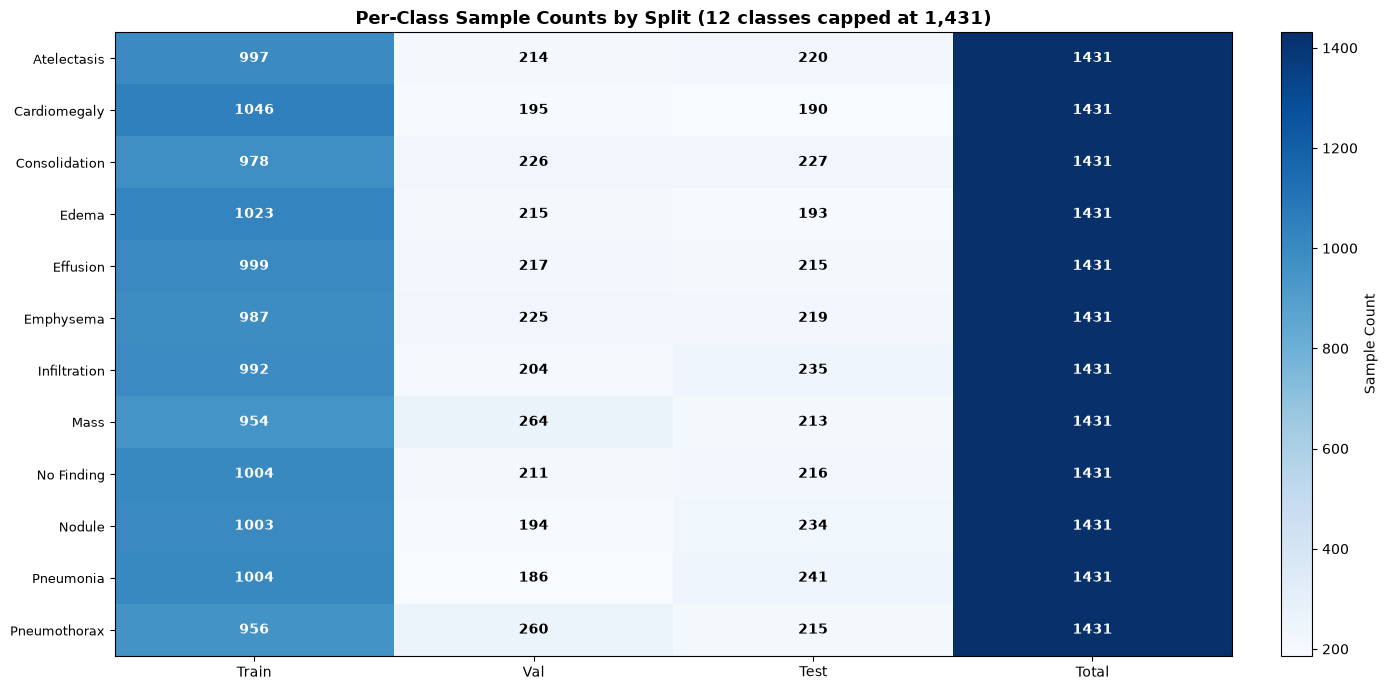

Chart saved to C:\RIE\outputs\eda\split_class_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

data = []
for lbl, name in label_map.items():
    row = [name]
    for df in dfs:
        row.append(int((df['label'] == lbl).sum()))
    row.append(sum(row[1:]))
    data.append(row)

tbl = pd.DataFrame(data, columns=['Class', 'Train', 'Val', 'Test', 'Total'])
tbl = tbl.set_index('Class').astype(int)

cmap = plt.cm.Blues
norm = plt.Normalize(tbl.values.min(), tbl.values.max())
im = ax.imshow(tbl.values, cmap=cmap, aspect='auto', norm=norm)
ax.set_xticks(range(len(tbl.columns)))
ax.set_xticklabels(tbl.columns, fontsize=10)
ax.set_yticks(range(len(tbl.index)))
ax.set_yticklabels(tbl.index, fontsize=9)

threshold = (tbl.values.max() + tbl.values.min()) / 2
for i in range(len(tbl.index)):
    for j in range(len(tbl.columns)):
        color = 'white' if tbl.values[i, j] > threshold else 'black'
        ax.text(j, i, str(tbl.values[i, j]),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color=color)

ax.set_title('Per-Class Sample Counts by Split (12 classes capped at 1,431)',
             fontsize=13, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Sample Count', fontsize=10)
plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'split_class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {EDA_OUTPUT / "split_class_distribution.png"}')


## Patient Leakage Verification

In [5]:
# Identify patient ID column (fuzzy match)
pid_col = None
for c in ['patient_id', 'Patient ID', 'pid', 'pid_str']:
    if c in df_train.columns:
        pid_col = c
        break
if pid_col is None:
    matches = [c for c in df_train.columns if 'patient' in c.lower() or 'pid' in c.lower()]
    pid_col = matches[0] if matches else df_train.columns[0]

train_pids = set(df_train[pid_col].astype(str).unique())
val_pids   = set(df_val[pid_col].astype(str).unique())
test_pids  = set(df_test[pid_col].astype(str).unique())
tv = train_pids & val_pids
tt = train_pids & test_pids
vt = val_pids   & test_pids

print('Patient leakage check:')
print(f'  Train ∩ Val  : {len(tv)} overlap (must be 0)')
print(f'  Train ∩ Test : {len(tt)} overlap (must be 0)')
print(f'  Val   ∩ Test : {len(vt)} overlap (must be 0)')

assert len(tv) == 0, 'LEAKAGE: Train/Val overlap'
assert len(tt) == 0, 'LEAKAGE: Train/Test overlap'
assert len(vt) == 0, 'LEAKAGE: Val/Test overlap'
print('\n✅ Zero patient leakage confirmed across all splits.')

Patient leakage check:
  Train ∩ Val  : 0 overlap (must be 0)
  Train ∩ Test : 0 overlap (must be 0)
  Val   ∩ Test : 0 overlap (must be 0)

✅ Zero patient leakage confirmed across all splits.


## Source Weight Distribution (Training Set)

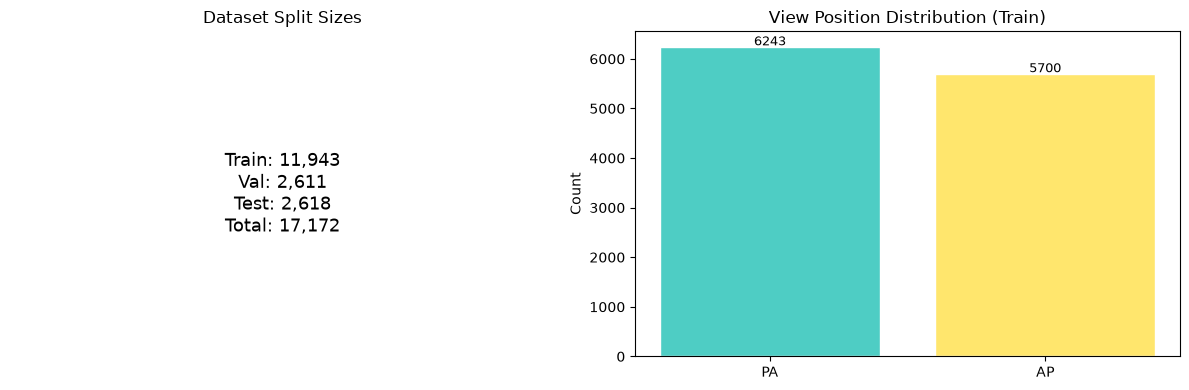

Chart saved to C:\RIE\outputs\eda\preprocessing_summary.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training set size summary
ax = axes[0]
ax.text(0.5, 0.5, f'Train: {len(df_train):,}\nVal: {len(df_val):,}\nTest: {len(df_test):,}\nTotal: {len(df_train)+len(df_val)+len(df_test):,}',
        ha='center', va='center', transform=ax.transAxes, fontsize=13)
ax.set_title('Dataset Split Sizes')
ax.axis('off')

# View position breakdown (training)
ax = axes[1]
if 'view_position' in df_train.columns:
    vp_counts = df_train['view_position'].value_counts()
    colors = ['#4ECDC4', '#FFE66D', '#FF6B6B'][:len(vp_counts)]
    bars = ax.bar(vp_counts.index, vp_counts.values, color=colors, edgecolor='white')
    ax.set_title('View Position Distribution (Train)')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, vp_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(v), ha='center', fontsize=9)
    ax.tick_params(axis='x', labelsize=10)
else:
    ax.text(0.5, 0.5, 'No view_position data',
            ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'preprocessing_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {EDA_OUTPUT / "preprocessing_summary.png"}')

## Preprocessing Complete
All splits validated. Proceed to `EDA.ipynb` for
exploratory analysis, then run model notebooks for training.